In [1]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import (

    DecisionTreeClassifier,

    plot_tree,

    export_text
)

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report
)

from sklearn.utils import resample

In [3]:
df = pd.read_json(
    "../data/processed/classification_data.json"
)

df.head()

,avg_male_weight,avg_female_weight,hypoallergenic,is_large
0,4.0,4.0,1,0
1,25.0,22.5,0,1
2,21.5,19.0,0,0
3,47.5,42.5,0,1
4,6.5,6.5,0,0


In [4]:
df['is_large'].value_counts()

is_large
0    158
1    125
Name: count, dtype: int64

In [5]:
mayoria = df[df.is_large == 1]

minoria = df[df.is_large == 0]

minoria_oversample = resample(

    minoria,

    replace=True,

    n_samples=len(mayoria),

    random_state=42
)

df_balanceado = pd.concat([

    mayoria,

    minoria_oversample
])

df_balanceado['is_large'].value_counts()

is_large
1    125
0    125
Name: count, dtype: int64

In [6]:
y = df_balanceado['is_large']

X = df_balanceado[[

    'avg_male_weight',

    'avg_female_weight',

    'hypoallergenic'
]]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [8]:
modelo = DecisionTreeClassifier(

    random_state=42,

    max_depth=4
)

modelo.fit(

    X_train,

    y_train
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [9]:
y_pred = modelo.predict(X_test)

In [10]:
accuracy = accuracy_score(

    y_test,

    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [11]:
precision = precision_score(

    y_test,

    y_pred
)

print(f"Precision: {precision:.4f}")

Precision: 1.0000


In [12]:
recall = recall_score(

    y_test,

    y_pred
)

print(f"Recall: {recall:.4f}")

Recall: 1.0000


In [13]:
f1 = f1_score(

    y_test,

    y_pred
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 1.0000


In [14]:
print(

    classification_report(

        y_test,

        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [15]:
cm = confusion_matrix(

    y_test,

    y_pred
)

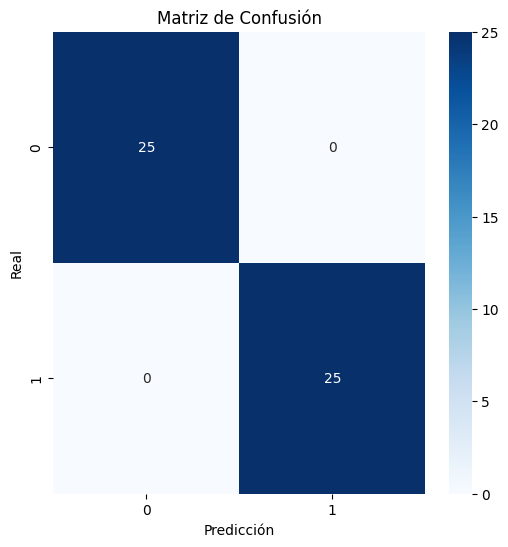

In [16]:
import seaborn as sns

plt.figure(figsize=(6,6))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'
)

plt.title("Matriz de Confusión")

plt.xlabel("Predicción")

plt.ylabel("Real")

plt.show()

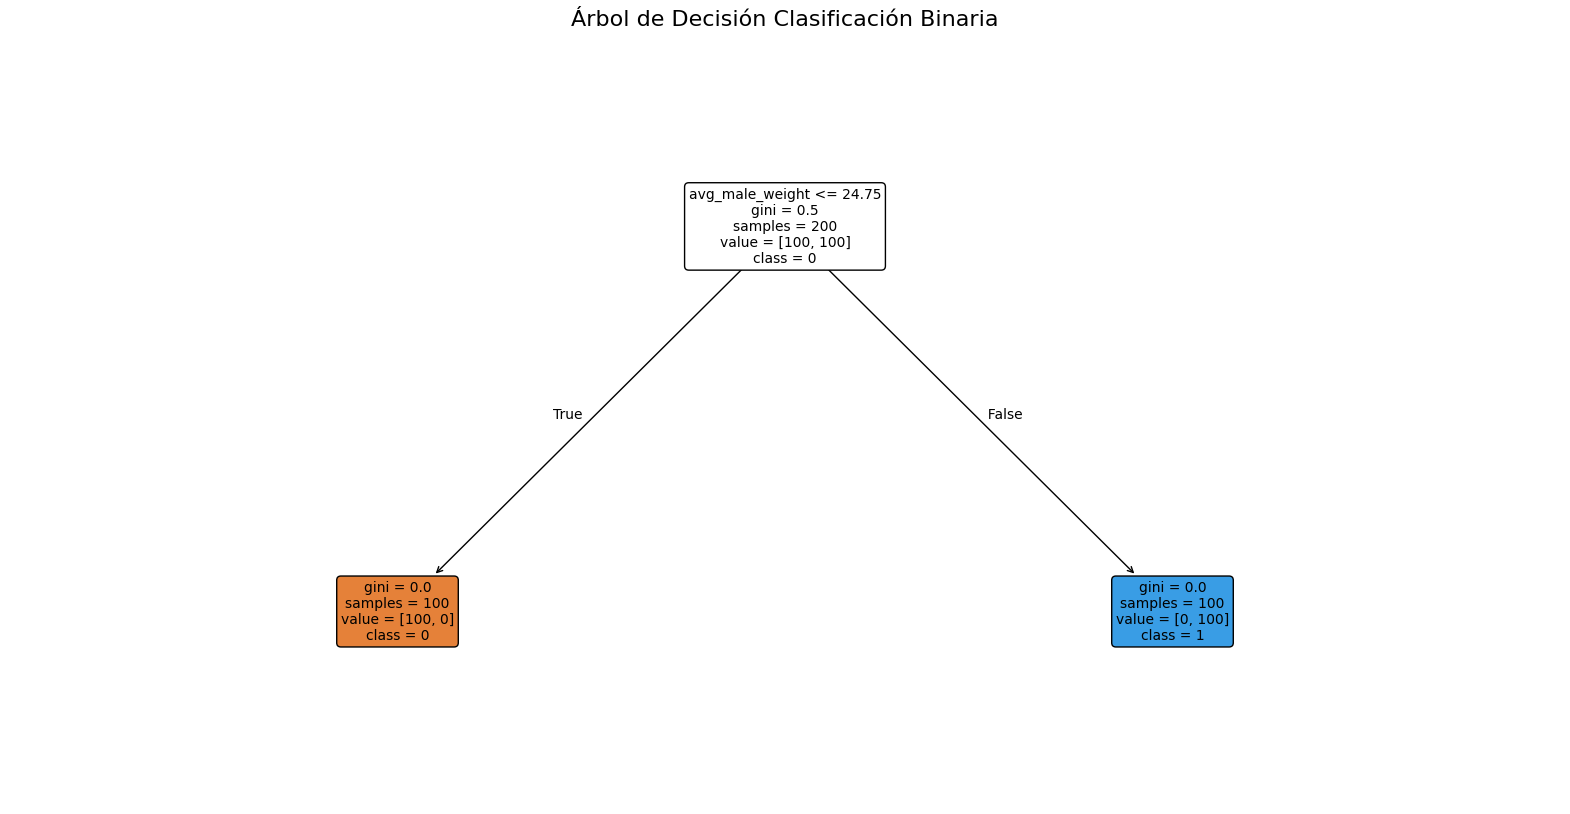

In [17]:
plt.figure(figsize=(20,10))

plot_tree(

    modelo,

    feature_names=X.columns,

    class_names=['0', '1'],

    filled=True,

    rounded=True,

    fontsize=10
)

plt.title(

    "Árbol de Decisión Clasificación Binaria",

    fontsize=16
)

plt.show()

In [18]:
reglas = export_text(

    modelo,

    feature_names=list(X.columns)
)

print(reglas)

|--- avg_male_weight <= 24.75
|   |--- class: 0
|--- avg_male_weight >  24.75
|   |--- class: 1

